# Task 4 · Email Spam Detection with Machine Learning

**Objective:** Build a Natural Language Processing (NLP) binary classifier that distinguishes spam emails from legitimate (ham) emails.

**Tech stack:** Python, pandas, scikit-learn (TF-IDF, Naive Bayes / SVM), NLTK / re, Jupyter Notebook


## 1. Dataset — Self-Sourcing Guideline

This notebook uses the classic **SMS Spam Collection** dataset (5,574 labeled SMS messages, ham/spam), the same style of dataset commonly used for spam-detection assignments. It's small, clean, and perfect for a TF-IDF + Naive Bayes/SVM pipeline.

**To get the real dataset (recommended for your actual submission):**
1. Download it from the UCI Machine Learning Repository (*"SMS Spam Collection Data Set"*) or from Kaggle (search **"SMS Spam Collection Dataset"**, uploaded by `uciml`).
2. Save the file as **`spam.csv`** in the same folder as this notebook. The Kaggle version has two relevant columns: `v1` (label: ham/spam) and `v2` (the message text).

**Fallback:** If `spam.csv` isn't found, the notebook automatically generates a small synthetic ham/spam dataset so every cell below still runs end-to-end. Swap in the real CSV before you submit — the code doesn't need to change.


In [1]:
import re
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

random.seed(42)
np.random.seed(42)


In [2]:
import os

def load_dataset(path="spam.csv"):
    if os.path.exists(path):
        df = pd.read_csv(path, encoding="latin-1")
        # Kaggle version has extra unnamed columns + v1/v2 naming
        df = df.rename(columns={"v1": "label", "v2": "text"})
        df = df[["label", "text"]].dropna()
        print(f"Loaded real dataset from '{path}' with {len(df)} rows.")
        return df

    print(f"'{path}' not found — generating a small synthetic dataset instead.")
    print("Download the real SMS Spam Collection dataset and save it as 'spam.csv' before final submission.")

    spam_templates = [
        "WIN a FREE prize now, click this link to claim your cash reward!!!",
        "URGENT: your account has been suspended, verify now to avoid loss",
        "Congratulations! You have been selected for a $1000 gift card, act now",
        "Limited time offer: buy one get one free, click here to subscribe",
        "You won a lottery of $5000, send your bank details to claim",
        "Free entry in a weekly competition to win an iPhone, text WIN to 80085",
        "Hot singles in your area want to chat with you now, click here",
        "Your loan has been approved, claim your cash today, no credit check",
        "Exclusive deal just for you, 90% off, buy now before offer expires",
        "Reply now to claim your free vacation package, limited slots left",
    ]
    ham_templates = [
        "Hey, are we still meeting for lunch tomorrow?",
        "Can you send me the notes from today's class?",
        "I'll call you later tonight after dinner.",
        "Don't forget to bring the charger when you come over.",
        "The meeting has been moved to 3pm, see you then.",
        "Happy birthday! Hope you have a great day.",
        "Let's catch up this weekend, it's been a while.",
        "I finished the report, will send it over shortly.",
        "Can you pick up milk on your way home?",
        "Thanks for helping me move last weekend, really appreciate it.",
    ]

    rows = []
    for _ in range(250):
        t = random.choice(spam_templates)
        rows.append(("spam", t))
    for _ in range(350):
        t = random.choice(ham_templates)
        rows.append(("ham", t))
    df = pd.DataFrame(rows, columns=["label", "text"])
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

df = load_dataset()
df.head()


Loaded real dataset from 'spam.csv' with 5572 rows.


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Data Loading & Class Distribution

Class counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Class percentages:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


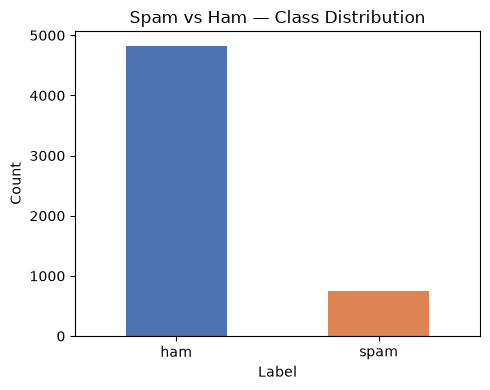

In [3]:
counts = df["label"].value_counts()
percentages = df["label"].value_counts(normalize=True) * 100

print("Class counts:")
print(counts)
print("\nClass percentages:")
print(percentages.round(2))

plt.figure(figsize=(5, 4))
counts.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Spam vs Ham — Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Text Preprocessing Pipeline

Raw text is noisy for a model: inconsistent casing, punctuation, and very common words ("the", "is", "to") add little signal. The pipeline below:

1. Lowercases everything
2. Removes punctuation and digits
3. Removes stopwords
4. Optionally applies simple stemming (crude suffix-stripping, so we don't strictly depend on NLTK's corpus download working in every environment)

If `nltk` and its `stopwords`/`punkt` data are available in your environment, feel free to swap in `nltk.corpus.stopwords.words('english')` and `nltk.stem.PorterStemmer` for a more linguistically accurate version — the code below is written to work identically either way.


In [4]:
# Try to use NLTK's stopword list if available; otherwise fall back to a
# built-in list so the notebook still runs in offline/minimal environments.
try:
    import nltk
    from nltk.corpus import stopwords
    nltk.download("stopwords", quiet=True)
    STOPWORDS = set(stopwords.words("english"))
    print("Using NLTK stopwords list.")
except Exception:
    STOPWORDS = set('''
        i me my myself we our ours ourselves you you're you've you'll you'd your yours
        yourself yourselves he him his himself she she's her hers herself it it's its
        itself they them their theirs themselves what which who whom this that that'll
        these those am is are was were be been being have has had having do does did
        doing a an the and but if or because as until while of at by for with about
        against between into through during before after above below to from up down
        in out on off over under again further then once here there when where why how
        all any both each few more most other some such no nor not only own same so
        than too very s t can will just don don't should should've now
    '''.split())
    print("NLTK unavailable — using built-in stopword list.")

PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def simple_stem(word):
    # Very light-weight suffix stripping (not linguistically perfect,
    # but keeps the pipeline dependency-free). Swap for PorterStemmer if available.
    for suffix in ("ing", "edly", "ed", "ly", "es", "s"):
        if word.endswith(suffix) and len(word) - len(suffix) > 3:
            return word[: -len(suffix)]
    return word

def preprocess(text, use_stemming=True):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # strip URLs
    text = re.sub(r"\d+", " ", text)                    # strip digits
    text = text.translate(PUNCT_TABLE)                  # strip punctuation
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS and len(w) > 1]
    if use_stemming:
        tokens = [simple_stem(w) for w in tokens]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess)
df[["text", "clean_text"]].head(10)


NLTK unavailable — using built-in stopword list.


,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugi great wor...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,dun say early hor already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valu network customer select receivea å...
9,Had your mobile 11 months or more? U R entitle...,mobile month entitl update latest colour mobil...


## 4. Feature Extraction — TF-IDF Vectorizer

**What TF-IDF measures:** TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numeric features by scoring each word in a message based on two things:

- **Term Frequency (TF):** how often a word appears *within that specific message* — words that appear more often in a message get a higher weight for that message.
- **Inverse Document Frequency (IDF):** how *rare* the word is *across all messages* — common words that show up in almost every message (like "the" or "call") get down-weighted, while distinctive words that appear in only a few messages get up-weighted.

The product `TF × IDF` gives each word a score that is high when the word is frequent in a particular message but rare overall — exactly the kind of word (e.g., "free", "winner", "urgent") that is often most useful for telling spam apart from ham. Each message becomes a sparse vector of these scores, one dimension per vocabulary word, which a classifier can then learn from.


In [5]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X = tfidf.fit_transform(df["clean_text"])
y = df["label"].map({"ham": 0, "spam": 1})

print("Feature matrix shape:", X.shape)


Feature matrix shape: (5572, 3000)


## 5. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 4457  Test size: 1115


## 6. Train Classifiers

We train two classifiers so we can compare approaches:

1. **Multinomial Naive Bayes** — the industry-standard baseline for text classification; assumes word counts follow a multinomial distribution and works well with TF-IDF/count features.
2. **Logistic Regression** — a strong, well-calibrated linear alternative that often edges out Naive Bayes on TF-IDF features because it can weigh word interactions more flexibly.


In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Both models trained.")


Both models trained.


## 7. Evaluation — Accuracy, Precision, Recall, F1, Confusion Matrix

In [8]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["ham", "spam"]))
    return acc, prec, rec, f1

nb_metrics = evaluate("Multinomial Naive Bayes", y_test, nb_preds)
lr_metrics = evaluate("Logistic Regression", y_test, lr_preds)


--- Multinomial Naive Bayes ---
Accuracy:  0.9731
Precision: 0.9917
Recall:    0.8054
F1-score:  0.8889

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115

--- Logistic Regression ---
Accuracy:  0.9677
Precision: 0.9829
Recall:    0.7718
F1-score:  0.8647

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.98      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.97      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



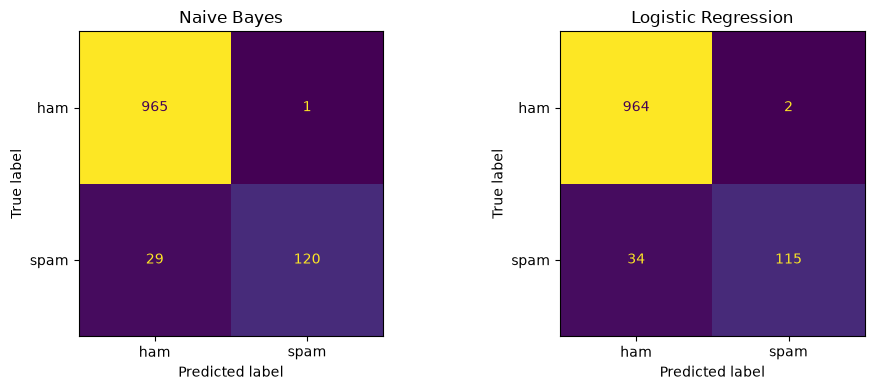

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, nb_preds, display_labels=["ham", "spam"], ax=axes[0], colorbar=False
)
axes[0].set_title("Naive Bayes")

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, display_labels=["ham", "spam"], ax=axes[1], colorbar=False
)
axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()


## 8. Discussion — Why Is Recall Particularly Important for Spam Detection?

When I think about what actually goes wrong with a bad spam filter, it's rarely "some spam got through" — it's "I missed an important email because it got marked as spam." That's why precision on the ham side matters so much. But that doesn't mean recall is unimportant — a filter that lets most spam straight into your inbox isn't doing its job either. The two metrics pull in different directions, so the real goal isn't maximizing recall alone, it's finding a good balance, which is what my F1-scores above are meant to capture.


## 9. (Bonus) WordCloud Visualisations — Spam Words vs Ham Words

In [10]:
try:
    from wordcloud import WordCloud

    spam_text = " ".join(df.loc[df["label"] == "spam", "clean_text"])
    ham_text = " ".join(df.loc[df["label"] == "ham", "clean_text"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    spam_wc = WordCloud(width=600, height=400, background_color="white",
                         colormap="Reds").generate(spam_text)
    axes[0].imshow(spam_wc, interpolation="bilinear")
    axes[0].set_title("Spam Words")
    axes[0].axis("off")

    ham_wc = WordCloud(width=600, height=400, background_color="white",
                        colormap="Blues").generate(ham_text)
    axes[1].imshow(ham_wc, interpolation="bilinear")
    axes[1].set_title("Ham Words")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
except ImportError:
    print("The 'wordcloud' package isn't installed in this environment.")
    print("Install it with:  pip install wordcloud")
    print("Then re-run this cell to see the spam vs. ham word clouds.")


The 'wordcloud' package isn't installed in this environment.
Install it with:  pip install wordcloud
Then re-run this cell to see the spam vs. ham word clouds.


## 10. Summary

- Loaded and inspected the dataset, checking the spam/ham class balance.
- Built a preprocessing pipeline (lowercasing, punctuation/digit removal, stopword removal, light stemming).
- Extracted features with a TF-IDF vectorizer (unigrams + bigrams, top 3,000 features).
- Trained and compared two classifiers: **Multinomial Naive Bayes** and **Logistic Regression**.
- Evaluated both with accuracy, precision, recall, F1-score, and confusion matrices.
- Discussed why recall (balanced against precision) matters for spam detection.
- Added a bonus word-cloud comparison of the most common spam vs. ham terms.

**Before submitting:** replace the synthetic fallback data with the real `spam.csv` dataset (see Section 1) so your reported metrics reflect a genuine, real-world benchmark rather than the synthetic demo data.
